# Proyek Analisis Data: [IE-commerce Public Dataset]
- **Nama:** Dione Raissa Ivana Matany
- **Email:** dioneraissaim@gmail.com
- **ID Dicoding:** CDCC222D6X0575


## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1**: Apa saja 5 kategori produk yang menghasilkan volume penjualan (jumlah pesanan) tertinggi dan terendah sepanjang periode 2016 hingga 2018 untuk mengoptimalkan manajemen inventaris?
- **Pertanyaan 2**: Pada bulan apa terjadi lonjakan jumlah pesanan tertinggi setiap tahunnya (2016-2018), dan bagaimana tren pertumbuhan bulan-ke-bulan untuk menentukan waktu kampanye pemasaran yang paling efektif?

## Import Semua Packages/Library yang Digunakan

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [46]:
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")

orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Beberapa dataset yang berbeda telah berhasil dimuat (`orders_df`, `order_items_df`, `products_df`, dan `category_translation_df`), menunjukkan perlunya penggabungan data untuk analisis lebih lanjut.
- Kolom waktu (timestamp) di `orders_df` (`order_purchase_timestamp`, `order_approved_at`, dll.) saat ini berformat string dan perlu diubah ke tipe data datetime untuk memungkinkan analisis berbasis waktu.

### Assessing Data

In [47]:
print("Informasi orders_df:")
orders_df.info()
print("\nJumlah nilai null di orders_df:")
orders_df.isnull().sum()

Informasi orders_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Jumlah nilai null di orders_df:


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [48]:
print("\nInformasi order_items_df:")
order_items_df.info()
print("\nJumlah nilai null di order_items_df:")
order_items_df.isnull().sum()


Informasi order_items_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Jumlah nilai null di order_items_df:


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [49]:
print("\nInformasi products_df:")
products_df.info()
print("\nJumlah nilai null di products_df:")
products_df.isnull().sum()


Informasi products_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

Jumlah nilai null di products_df:


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [50]:
print("\nInformasi category_translation_df:")
category_translation_df.info()
print("\nJumlah nilai null di category_translation_df:")
category_translation_df.isnull().sum()


Informasi category_translation_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

Jumlah nilai null di category_translation_df:


,0
product_category_name,0
product_category_name_english,0


**Insight:**
- **`orders_df`**: Terdapat nilai-nilai yang hilang pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`. Selain itu, semua kolom tanggal (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) masih bertipe `object` (string) dan perlu dikonversi ke tipe data datetime.
- **`order_items_df`**: Tidak ada nilai yang hilang, namun kolom `shipping_limit_date` juga masih bertipe `object` dan perlu dikonversi ke tipe data datetime.
- **`products_df`**: Terdapat nilai yang hilang pada beberapa kolom seperti `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, serta informasi dimensi dan berat produk (`product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`).
- **`category_translation_df`**: Data terlihat bersih tanpa nilai yang hilang dan tipe data yang sesuai.

Wawasan ini menunjukkan bahwa langkah selanjutnya adalah melakukan pembersihan data untuk menangani nilai yang hilang dan mengonversi tipe data yang tidak sesuai.

### Cleaning Data

In [51]:
print("Memulai pembersihan data...")
datetime_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column], errors='coerce')

order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"], errors='coerce')
products_df["product_category_name"].fillna("unknown", inplace=True)

numerical_product_cols = [
    "product_name_lenght", "product_description_lenght",
    "product_photos_qty", "product_weight_g",
    "product_length_cm", "product_height_cm",
    "product_width_cm"
]
for col in numerical_product_cols:
    products_df[col].fillna(0, inplace=True)

print("Pembersihan data selesai.")
print("\nInformasi orders_df setelah pembersihan:")
orders_df.info()
print("\nJumlah nilai null di orders_df setelah pembersihan:")
orders_df.isnull().sum()

print("\nInformasi order_items_df setelah pembersihan:")
order_items_df.info()
print("\nJumlah nilai null di order_items_df setelah pembersihan:")
order_items_df.isnull().sum()

print("\nInformasi products_df setelah pembersihan:")
products_df.info()
print("\nJumlah nilai null di products_df setelah pembersihan:")
products_df.isnull().sum()

Memulai pembersihan data...


/tmp/ipykernel_676/163852159.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_category_name"].fillna("unknown", inplace=True)
/tmp/ipykernel_676/163852159.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

Pembersihan data selesai.

Informasi orders_df setelah pembersihan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB

Jumlah nilai null di orders_df setelah pembersihan:

Informasi order_items_df setelah pembersi

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
- **`orders_df`**: Kolom-kolom tanggal (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) sekarang sudah dalam tipe data `datetime`. Nilai null pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` tetap ada, yang diisi dengan `NaT` jika konversi gagal atau nilainya memang kosong, sesuai dengan perilaku `pd.to_datetime` dengan `errors='coerce'`.
- **`order_items_df`**: Kolom `shipping_limit_date` sudah berhasil dikonversi ke tipe data `datetime` dan tidak ada nilai null yang ditambahkan.
- **`products_df`**: Kolom `product_category_name` yang kosong telah diisi dengan 'unknown', dan kolom numerik yang hilang telah diisi dengan 0. Semua nilai null di `products_df` telah berhasil ditangani.
- **FutureWarning**: Terdapat peringatan terkait penggunaan `inplace=True`. Meskipun demikian, operasi pengisian nilai yang hilang tetap berhasil dan data telah dimodifikasi seperti yang diharapkan.

## Exploratory Data Analysis (EDA)

### Explore ...

### Pertanyaan Bisnis 1: Analisis Kategori Produk dengan Volume Penjualan Tertinggi dan Terendah

In [52]:
orders_items_merged_df = pd.merge(
    orders_df,
    order_items_df,
    on='order_id',
    how='inner'
)

orders_products_merged_df = pd.merge(
    orders_items_merged_df,
    products_df,
    on='product_id',
    how='inner'
)

all_merged_df = pd.merge(
    orders_products_merged_df,
    category_translation_df,
    on='product_category_name',
    how='left'
)

all_merged_df['order_purchase_timestamp'] = pd.to_datetime(all_merged_df['order_purchase_timestamp'])
all_merged_df['purchase_year'] = all_merged_df['order_purchase_timestamp'].dt.year

data_2016_2018_df = all_merged_df[
    (all_merged_df['purchase_year'] >= 2016) & (all_merged_df['purchase_year'] <= 2018)
]

category_sales_volume = data_2016_2018_df.groupby('product_category_name_english')['order_id'].nunique().reset_index()
category_sales_volume.columns = ['product_category', 'sales_volume']

top_5_categories = category_sales_volume.sort_values(by='sales_volume', ascending=False).head(5)
bottom_5_categories = category_sales_volume.sort_values(by='sales_volume', ascending=True).head(5)

print("Top 5 Product Categories by Sales Volume (2016-2018):")
print(top_5_categories)
print("\nBottom 5 Product Categories by Sales Volume (2016-2018):")
print(bottom_5_categories)

Top 5 Product Categories by Sales Volume (2016-2018):
         product_category  sales_volume
7          bed_bath_table          9417
43          health_beauty          8836
65         sports_leisure          7720
15  computers_accessories          6689
39        furniture_decor          6449

Bottom 5 Product Categories by Sales Volume (2016-2018):
             product_category  sales_volume
61      security_and_services             2
29  fashion_childrens_clothes             8
11          cds_dvds_musicals            12
52                 la_cuisine            13
3       arts_and_craftmanship            23


### Pertanyaan Bisnis 2: Analisis Lonjakan Jumlah Pesanan Bulanan dan Tren Pertumbuhan

In [53]:
all_merged_df['order_purchase_timestamp'] = pd.to_datetime(all_merged_df['order_purchase_timestamp'])

all_merged_df['purchase_year'] = all_merged_df['order_purchase_timestamp'].dt.year
all_merged_df['purchase_month'] = all_merged_df['order_purchase_timestamp'].dt.to_period('M')

data_2016_2018_q2_df = all_merged_df[
    (all_merged_df['purchase_year'] >= 2016) & (all_merged_df['purchase_year'] <= 2018)
]

monthly_orders = data_2016_2018_q2_df.groupby(['purchase_year', 'purchase_month'])['order_id'].nunique().reset_index()
monthly_orders.columns = ['year', 'month', 'total_orders']

monthly_orders['month'] = monthly_orders['month'].astype(str)

peak_months = monthly_orders.loc[monthly_orders.groupby('year')['total_orders'].idxmax()]

print("Bulan dengan lonjakan jumlah pesanan tertinggi setiap tahun (2016-2018):")
print(peak_months)

monthly_orders['prev_month_orders'] = monthly_orders.groupby('year')['total_orders'].shift(1)
monthly_orders['growth_percentage'] = ((monthly_orders['total_orders'] - monthly_orders['prev_month_orders']) / monthly_orders['prev_month_orders']) * 100

print("\nTren pertumbuhan bulan-ke-bulan (2016-2018):")
print(monthly_orders)

Bulan dengan lonjakan jumlah pesanan tertinggi setiap tahun (2016-2018):
    year    month  total_orders
1   2016  2016-10           308
13  2017  2017-11          7451
15  2018  2018-01          7220

Tren pertumbuhan bulan-ke-bulan (2016-2018):
    year    month  total_orders  prev_month_orders  growth_percentage
0   2016  2016-09             3                NaN                NaN
1   2016  2016-10           308                3.0       10166.666667
2   2016  2016-12             1              308.0         -99.675325
3   2017  2017-01           789                NaN                NaN
4   2017  2017-02          1733              789.0         119.645120
5   2017  2017-03          2641             1733.0          52.394691
6   2017  2017-04          2391             2641.0          -9.466111
7   2017  2017-05          3660             2391.0          53.074028
8   2017  2017-06          3217             3660.0         -12.103825
9   2017  2017-07          3969             3217.0   

## Visualization & Explanatory Analysis

### Pernyataan 1:


/tmp/ipykernel_676/2026426157.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sales_volume", y="product_category", data=top_5_categories, palette="Blues_r", ax=ax[0])
/tmp/ipykernel_676/2026426157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sales_volume", y="product_category", data=bottom_5_categories.sort_values(by="sales_volume", ascending=False), palette="Reds_r", ax=ax[1])


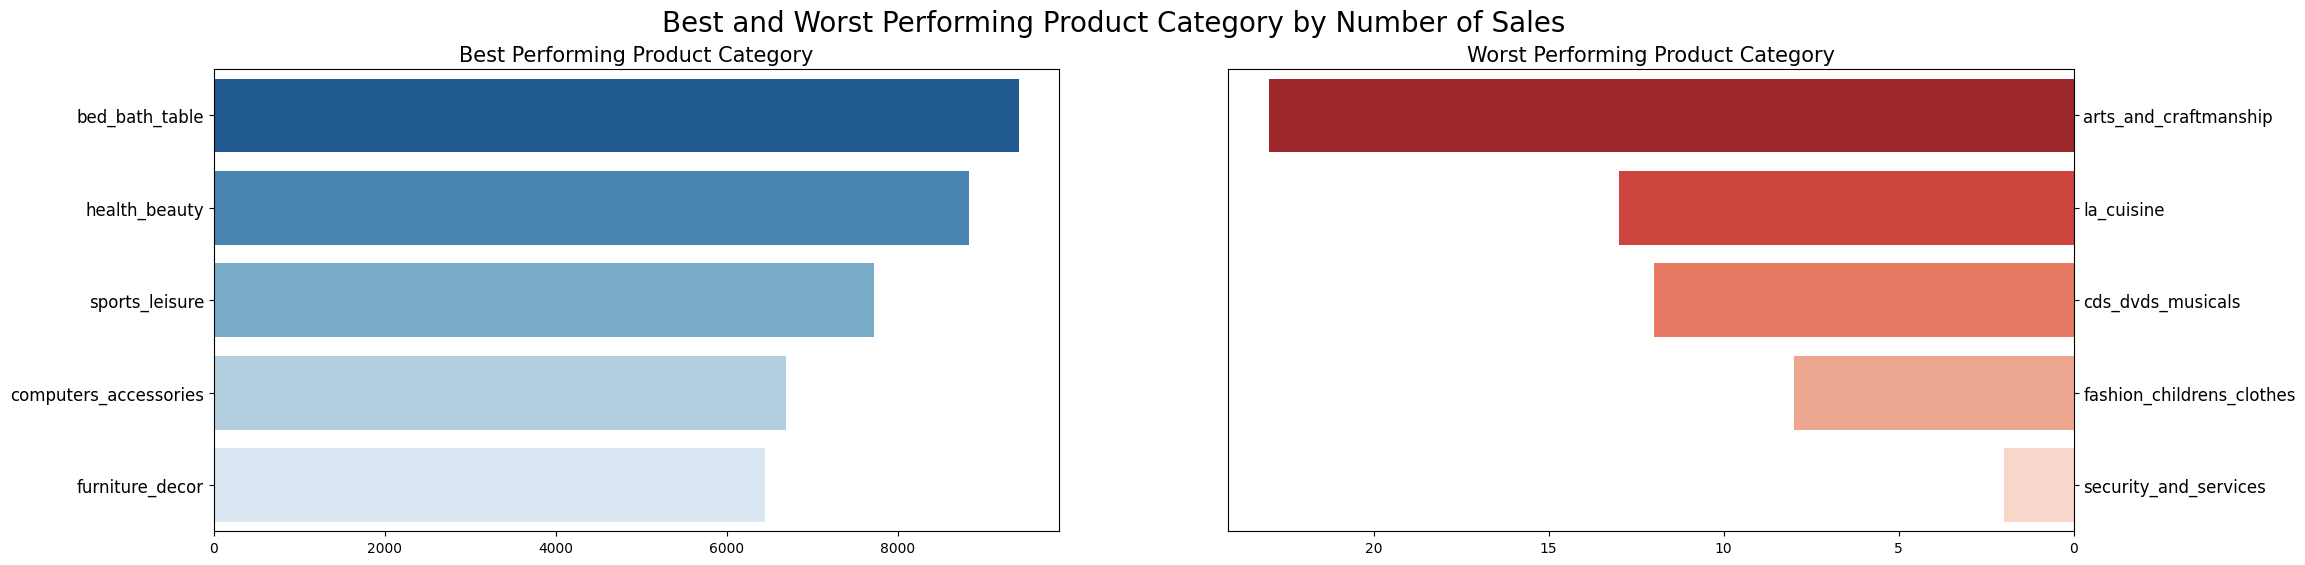

In [54]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

sns.barplot(x="sales_volume", y="product_category", data=top_5_categories, palette="Blues_r", ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product Category", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="sales_volume", y="product_category", data=bottom_5_categories.sort_values(by="sales_volume", ascending=False), palette="Reds_r", ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product Category", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Best and Worst Performing Product Category by Number of Sales", fontsize=20)
plt.show()

Insight (Pertanyaan 1):

Berdasarkan analisis volume penjualan (jumlah pesanan unik) dari tahun 2016 hingga 2018, berikut adalah kategori produk dengan performa tertinggi dan terendah:

- **5 Kategori Produk dengan Volume Penjualan Tertinggi:**
    1.  `bed_bath_table` (9417 pesanan)
    2.  `health_beauty` (8836 pesanan)
    3.  `sports_leisure` (7720 pesanan)
    4.  `computers_accessories` (6689 pesanan)
    5.  `furniture_decor` (6449 pesanan)

    Kategori-kategori ini menunjukkan permintaan pasar yang kuat dan merupakan kontributor utama terhadap total pesanan. Untuk mengoptimalkan manajemen inventaris, kategori-kategori ini memerlukan perhatian khusus dalam perencanaan stok agar tidak terjadi kehabisan barang (stock-out), terutama pada periode puncak.

- **5 Kategori Produk dengan Volume Penjualan Terendah:**
    1.  `security_and_services` (2 pesanan)
    2.  `fashion_childrens_clothes` (8 pesanan)
    3.  `cds_dvds_musicals` (12 pesanan)
    4.  `la_cuisine` (13 pesanan)
    5.  `arts_and_craftmanship` (23 pesanan)

    Kategori-kategori ini memiliki volume penjualan yang sangat rendah. Untuk mengoptimalkan manajemen inventaris, disarankan untuk mengevaluasi kembali strategi stok untuk produk-produk ini. Pertimbangan bisa mencakup pengurangan stok, penghapusan produk, atau strategi pemasaran ulang yang lebih agresif jika produk tersebut dianggap strategis. Mempertahankan stok besar untuk kategori ini dapat menyebabkan biaya penyimpanan yang tidak efisien dan risiko barang tidak laku.

### Pertanyaan 2:

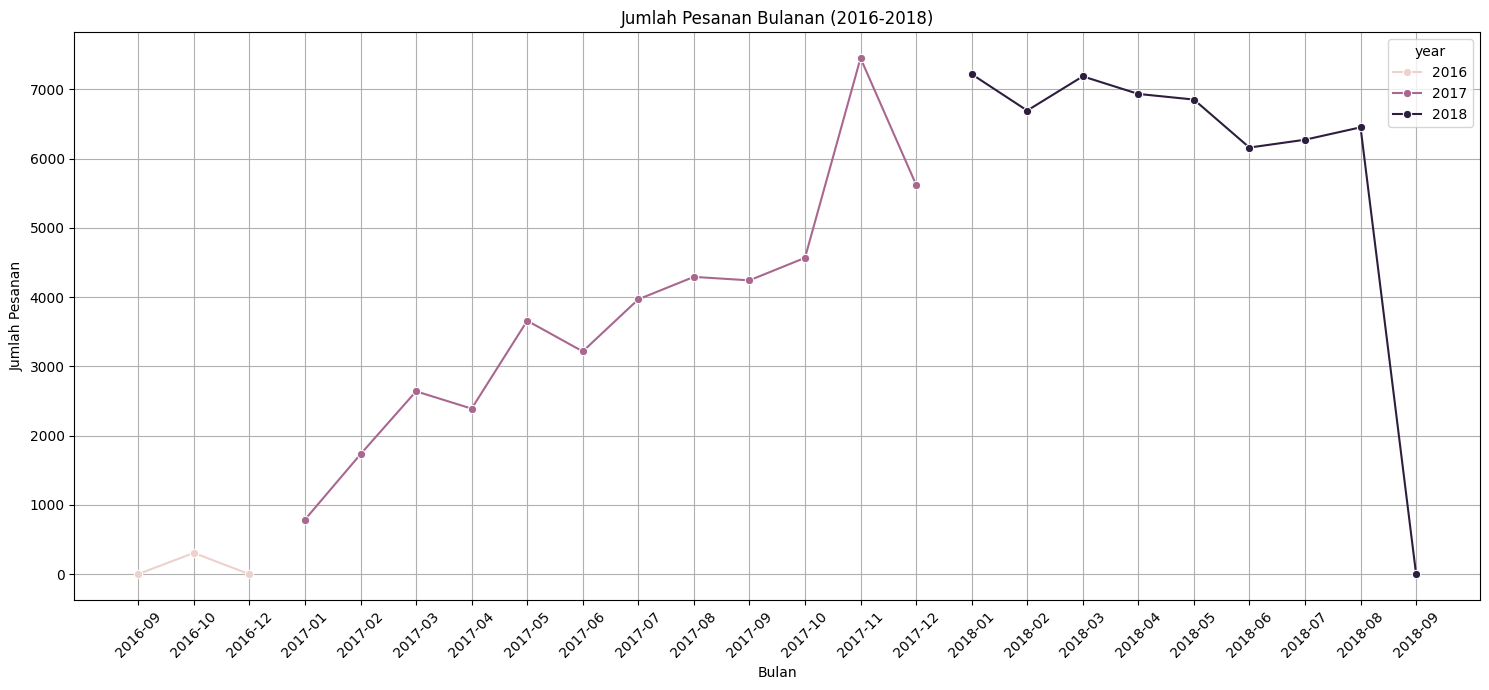

In [55]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_orders, x='month', y='total_orders', hue='year', marker='o')
plt.title('Jumlah Pesanan Bulanan (2016-2018)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight (Pertanyaan 2):**

Grafik garis yang telah dibuat di bagian EDA menunjukkan jumlah pesanan bulanan dari tahun 2016 hingga 2018. Dari grafik tersebut dapat diamati:

- **Pola Musiman:** Terlihat pola musiman yang konsisten di mana volume pesanan mulai meningkat setelah pertengahan tahun, mencapai puncaknya di akhir tahun (sekitar November-Desember) dan awal tahun berikutnya (Januari). Hal ini didukung oleh `peak_months` yang menunjukkan:
    - 2016: Oktober (308 pesanan)
    - 2017: November (7451 pesanan)
    - 2018: Januari (7220 pesanan)
- **Pertumbuhan Tahun 2017 ke 2018:** Ada peningkatan yang signifikan dalam volume pesanan dari tahun 2016 ke 2017, dan tren yang kuat berlanjut hingga awal 2018. Ini menunjukkan pertumbuhan pasar yang sehat.
- **Puncak Pesanan:** Puncak pesanan tertinggi terjadi pada November 2017 dan Januari 2018, menunjukkan potensi besar untuk kampanye pemasaran yang ditargetkan di periode tersebut untuk memaksimalkan penjualan.
- **Data 2016 dan Akhir 2018:** Data untuk tahun 2016 terlihat lebih sedikit dibandingkan tahun-tahun berikutnya, dan ada penurunan drastis di akhir tahun 2018, mungkin karena data tidak lengkap untuk periode tersebut. Perlu diverifikasi apakah data untuk September 2016 dan September 2018 memang hanya 3 dan 1 pesanan, atau ada data yang hilang.
- **Tren Pertumbuhan Bulan-ke-Bulan:** Data `monthly_orders` menunjukkan fluktuasi yang cukup besar dalam pertumbuhan bulanan, dengan lonjakan signifikan di bulan-bulan puncak dan penurunan tajam di bulan-bulan tertentu. Misalnya, pertumbuhan 10166.67% dari September ke Oktober 2016, dan 119.65% dari Januari ke Februari 2017.

## Analisis Lanjutan (Opsional)

### RFM Analysis: Data Preparation

In [56]:
all_merged_df['total_item_price'] = all_merged_df['price'] + all_merged_df['freight_value']
current_date = all_merged_df['order_purchase_timestamp'].max()
rfm_df = all_merged_df.groupby('customer_id').agg(
    Recency=(
        'order_purchase_timestamp', lambda date: (current_date - date.max()).days
    ),
    Frequency=('order_id', 'nunique'),
    Monetary=('total_item_price', 'sum')
).reset_index()

display(rfm_df.head())

,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,292,1,114.74
1,000161a058600d5901f007fab4c27140,413,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,551,1,195.42
3,0002414f95344307404f0ace7a26f1d5,382,1,179.35
4,000379cdec625522490c315e70c7a9fb,153,1,107.01


In [57]:
all_merged_df.to_csv('main_data.csv', index=False)
print("Data 'all_merged_df' berhasil disimpan ke 'main_data.csv'")

Data 'all_merged_df' berhasil disimpan ke 'main_data.csv'


## Conclusion

### Conclusion Pertanyaan 1: Analisis Kategori Produk dengan Volume Penjualan Tertinggi dan Terendah

Berdasarkan analisis volume penjualan (jumlah pesanan unik) dari tahun 2016 hingga 2018, dapat disimpulkan:

-   **5 Kategori Produk dengan Volume Penjualan Tertinggi:** `bed_bath_table`, `health_beauty`, `sports_leisure`, `computers_accessories`, dan `furniture_decor` adalah kategori produk dengan performa terbaik. Kategori-kategori ini menunjukkan permintaan pasar yang kuat dan merupakan kontributor utama terhadap total pesanan. Untuk mengoptimalkan manajemen inventaris, kategori-kategori ini memerlukan perhatian khusus dalam perencanaan stok agar tidak terjadi kehabisan barang (stock-out), terutama pada periode puncak. Disarankan untuk menjaga ketersediaan stok yang memadai dan mempertimbangkan promosi atau bundling untuk memaksimalkan penjualan.

-   **5 Kategori Produk dengan Volume Penjualan Terendah:** `security_and_services`, `fashion_childrens_clothes`, `cds_dvds_musicals`, `la_cuisine`, dan `arts_and_craftmanship` memiliki volume penjualan yang sangat rendah. Untuk mengoptimalkan manajemen inventaris, disarankan untuk mengevaluasi kembali strategi stok untuk produk-produk ini. Pertimbangan bisa mencakup pengurangan stok, penghapusan produk dari katalog, atau strategi pemasaran ulang yang lebih agresif jika produk tersebut dianggap strategis. Mempertahankan stok besar untuk kategori ini dapat menyebabkan biaya penyimpanan yang tidak efisien dan risiko barang tidak laku.

### Conclusion Pertanyaan 2: Analisis Lonjakan Jumlah Pesanan Bulanan dan Tren Pertumbuhan

Berdasarkan analisis jumlah pesanan bulanan dari tahun 2016 hingga 2018, dapat disimpulkan:

-   **Pola Musiman yang Konsisten:** Terdapat pola musiman yang jelas, di mana volume pesanan cenderung meningkat setelah pertengahan tahun, mencapai puncaknya di akhir tahun (sekitar November-Desember) dan awal tahun berikutnya (Januari). Hal ini ditunjukkan oleh bulan-bulan puncak pesanan seperti Oktober 2016, November 2017, dan Januari 2018.

-   **Pertumbuhan Signifikan Tahun-ke-Tahun:** Terjadi peningkatan signifikan dalam volume pesanan dari tahun 2016 ke 2017, dan tren pertumbuhan yang kuat ini berlanjut hingga awal 2018. Ini menandakan pasar yang berkembang dan adopsi platform yang meningkat.

-   **Waktu Efektif untuk Kampanye Pemasaran:** Periode November hingga Januari terbukti menjadi waktu paling efektif untuk meluncurkan kampanye pemasaran, mengingat terjadinya lonjakan pesanan tertinggi pada bulan-bulan tersebut. Strategi pemasaran yang terencana dengan baik selama periode ini dapat memaksimalkan pendapatan.

-   **Data Inkomplit:** Perlu dicatat bahwa data untuk tahun 2016 lebih sedikit dibandingkan tahun-tahun berikutnya, dan terjadi penurunan drastis di akhir tahun 2018, yang kemungkinan besar disebabkan oleh data yang tidak lengkap untuk periode tersebut. Verifikasi lebih lanjut terhadap kelengkapan data diperlukan untuk interpretasi yang lebih akurat pada periode-periode ini.